Hierarchische Cluster-Analyse der Federalist Papers

In [1]:
# Korpusdatei runterladen
import urllib.request
import urllib.error

url = "https://www.gutenberg.org/cache/epub/18/pg18.txt"

# Korpusdatei als federalist.txt runterladen
try:
    urllib.request.urlretrieve(url, "federalist.txt")
    print("Federalist Papiere Korpus erfolgreich heruntergeladen!")

# Fehlerhandlung
except urllib.error.URLError as fehler:
    print(f"Fehler beim Runterladen: {fehler}")

Federalist Papiere Korpus erfolgreich heruntergeladen!


Anzahl der Papiere gefunden: 85
Starte TF-IDF-Vektorisierung...
TF-IDF-Matrix erfolgreich erstellt: (85, 1000)


C:\Users\K\AppData\Local\Temp\ipykernel_18340\2958074281.py:100: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  verknuepfungen = linkage(aehnlichkeit, 'ward')


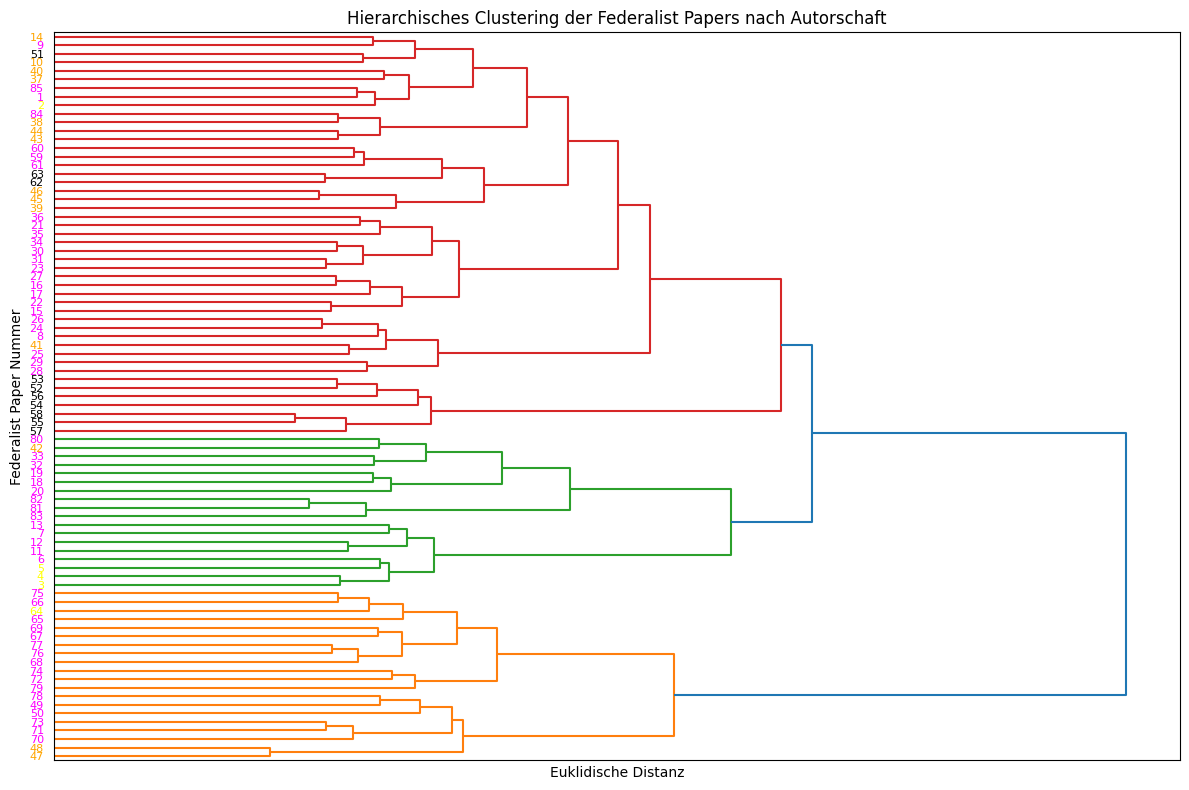


Urheberschafts-Zuordnung:
  Paper 1: Hamilton
  Paper 2: Jay
  Paper 3: Jay
  Paper 4: Jay
  Paper 5: Jay
  Paper 6: Hamilton
  Paper 7: Hamilton
  Paper 8: Hamilton
  Paper 9: Hamilton
  Paper 10: Madison
  Paper 11: Hamilton
  Paper 12: Hamilton
  Paper 13: Hamilton
  Paper 14: Madison
  Paper 15: Hamilton
  Paper 16: Hamilton
  Paper 17: Hamilton
  Paper 18: Hamilton
  Paper 19: Hamilton
  Paper 20: Hamilton
  Paper 21: Hamilton
  Paper 22: Hamilton
  Paper 23: Hamilton
  Paper 24: Hamilton
  Paper 25: Hamilton
  Paper 26: Hamilton
  Paper 27: Hamilton
  Paper 28: Hamilton
  Paper 29: Hamilton
  Paper 30: Hamilton
  Paper 31: Hamilton
  Paper 32: Hamilton
  Paper 33: Hamilton
  Paper 34: Hamilton
  Paper 35: Hamilton
  Paper 36: Hamilton
  Paper 37: Madison
  Paper 38: Madison
  Paper 39: Madison
  Paper 40: Madison
  Paper 41: Madison
  Paper 42: Madison
  Paper 43: Madison
  Paper 44: Madison
  Paper 45: Madison
  Paper 46: Madison
  Paper 47: Madison
  Paper 48: Madison
  Paper 

In [6]:
# HCA Federalist Papiere
import re
import nltk
import os
from pandas import DataFrame
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Öffne die Textdatei
eingabedatei = open("federalist.txt", "r", encoding="utf8")
text = eingabedatei.read()
eingabedatei.close()

# Entferne den Projektgutenberg-Standard-Fußtext
text = re.sub(r'\*\*\* END OF THE PROJECT GUTENBERG.*', '', text, flags=re.DOTALL)

# Entferne die zweite Version von No. 70
text = re.sub(
    r'THE FEDERALIST\.\s+No\.\s+LXX\..*?\(There are two slightly different versions of No\. 70 included here\.\).*?(?=THE FEDERALIST\.\s+No\.|$)',
    '',
    text,
    flags=re.DOTALL
)

# Extrahiere alle Papiere mit Titel und Inhalt (nicht splitten!)
papiere = re.findall(
    r'THE FEDERALIST\.\s+No\.\s+[A-Z0-9]+\..*?(?=THE FEDERALIST\.\s+No\.|$)',
    text,
    re.DOTALL
)

print(f"Anzahl der Papiere gefunden: {len(papiere)}")

# Erstelle Papier-Nummern
papier_nummern = [i + 1 for i in range(len(papiere))]

# Erstelle ein Wörterbuch mit den Urheberschaftsinformationen
urheberschaft = {}
marker_typ = {}  # "AND", "OR", oder None für eindeutige

for i, papier_inhalt in enumerate(papiere):
    papier_nr = i + 1
    
    # Suche nach Autoren-Info in Großbuchstaben
    autoren_match = re.search(
        r'(HAMILTON|MADISON|JAY)\s+(AND|OR)\s+(HAMILTON|MADISON|JAY)',
        papier_inhalt,
        re.IGNORECASE
    )

    unbekannte_papiere = [51, 52, 53, 54, 55, 56, 57, 58, 62, 63]  

    if papier_nr in unbekannte_papiere:
        urheberschaft[str(papier_nr)] = "Unbekannt"
        marker_typ[papier_nr] = None
    elif autoren_match:
        autor1 = autoren_match.group(1).capitalize()
        operator = autoren_match.group(2).upper()
        autor2 = autoren_match.group(3).capitalize()
        
        # Speichere den ersten Autor als Standardwert
        urheberschaft[str(papier_nr)] = autor1
        marker_typ[papier_nr] = operator
    else:
        # Fallback auf die ursprüngliche Logik
        marker_typ[papier_nr] = None  # Eindeutig
        if papier_nr == 10 or papier_nr == 14 or (papier_nr >= 18 and papier_nr <= 20) or (papier_nr >= 37 and papier_nr <= 48):
            urheberschaft[str(papier_nr)] = "Madison"
        elif (papier_nr >= 2 and papier_nr <= 5) or papier_nr == 64:
            urheberschaft[str(papier_nr)] = "Jay"
        else:
            urheberschaft[str(papier_nr)] = "Hamilton"

# Weise jeder Autor eine Farbe zu
autor_farben = {
    "Hamilton": "magenta",
    "Madison": "orange",
    "Jay": "yellow",
    "Unbekannt": "black"
}

# Führe die TF-IDF-Analyse durch
print("Starte TF-IDF-Vektorisierung...")
tfidf_vektorisierer = TfidfVectorizer(
    max_features=1000,
    use_idf=False,
    min_df=2,
    max_df=0.9,
    stop_words='english'
)

tfidf_matrix = tfidf_vektorisierer.fit_transform(papiere)
print(f"TF-IDF-Matrix erfolgreich erstellt: {tfidf_matrix.shape}")

# Berechne euklidische Abstände und hierarchisches Clustering
aehnlichkeit = euclidean_distances(tfidf_matrix)
verknuepfungen = linkage(aehnlichkeit, 'ward')

# Erstelle das Dendrogramm
plt.figure(figsize=(12, 8))
dendrogram(
    verknuepfungen,
    labels=papier_nummern,
    orientation='right',
    leaf_font_size=8
)
plt.xlabel('Euklidische Distanz')
plt.ylabel('Federalist Paper Nummer')
plt.title('Hierarchisches Clustering der Federalist Papers nach Autorschaft')
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
plt.tight_layout()

# Färbe die Y-Achsen-Labels basierend auf der Urheberschaft
ax = plt.gca()
beschriftungen = ax.get_ymajorticklabels()
for beschriftung in beschriftungen:
    papier_text = beschriftung.get_text()
    if papier_text and papier_text.isdigit():
        beschriftung.set_color(autor_farben[urheberschaft[papier_text]])

plt.show()

print("\nUrheberschafts-Zuordnung:")
for papier_nr in range(1, len(papiere) + 1):
    autor = urheberschaft[str(papier_nr)]
    print(f"  Paper {papier_nr}: {autor}")
